# Comparing the Impact of COVID-19 Policies on Mental Health Across the U.S.

## Overview (README)

"*How heavily did a state’s COVID-19 measurement policy have an impact on mental health 
compared to its counterparts?*"

**Team:** Buchard Joseph, Dominic Kraemer

**TL;DR.** Our final model beats the constant baseline by ~4% in terms of RMSE — policy stringency alone is a quite weak predictor of state-level mental-health outcomes.

- **Target variable:** `Value` - reported rate in % of depression/anxiety symptoms from CDC household surveys
- **Features:** `StringencyIndex_Average`, `EconomicSupportIndex`
- **Final dataset shape:** 11,412 x 50

- **Phase 1:** Defined the research question and identified the two data sources for the project.
- **Phase 2:** Merged the datasets via a left join of CDC survey data onto OxCGRT and ran EDA, which showed visible differences in reported depression/anxiety rates between age groups and states, and a weak linear relationship between `StringencyIndex_Average` and symptom rates within a state.
- **Phase 3:** Built a constant baseline (RMSE ≈ 7.51) and an SLR using `StringencyIndex_Average` that produced `Value = 30.47 + 0.093 * StringencyIndex_Average` (in-sample RMSE ≈ 7.31); the residual plot showed a funnel shape, hinting that stringency alone does not capture the structure in the data.
- **Phase 4:** Introduced an 80/20 train/test split, retrained the SLR (test RMSE ≈ 7.05), and added a `StringencyIndex × EconomicSupportIndex` interaction plus a binned stringency variable (after rejecting a log transform). Test RMSE improved only marginally with a small train–test gap — the model is not overfitting, but policy stringency is a weak predictor of population-level mental-health symptoms.

---

## 1. Data Loading and Cleaning

We combine two public datasets to answer our research question:

- **CDC Indicators of Anxiety or Depression** (`data.cdc.gov`) — household survey estimates of depression and anxiety symptom rates in the U.S., broken down by state and demographic subgroup across rolling time periods from April 2020 to September 2024. This is our **target source** (`Value`).
- **Oxford COVID-19 Government Response Tracker — OxCGRT** (`github.com/OxCGRT`) — daily numerical indices of how strict each U.S. state's COVID-19 policies were. This is our **feature source** (`StringencyIndex_Average`, `EconomicSupportIndex`).

The CDC data is reported per *time period*, while OxCGRT is reported *daily*, so the two cannot be joined directly. Our pipeline:

1. Filter OxCGRT to U.S. rows and drop columns we will not use (country identifiers, redundant `_combined` text columns).

In [154]:
import os
import urllib.request
import pandas as pd
import numpy as np

# --- 0. Download the source datasets ---
os.makedirs("dataset", exist_ok=True)

file_path_1 = "dataset/cdc_depression_data.csv"
file_path_2 = "dataset/OxCGRT_simplified_v1.csv"
file_path_3 = "dataset/final_dataset.csv"
url_path_1 = "https://data.cdc.gov/api/views/8pt5-q6wp/rows.csv?accessType=DOWNLOAD"
url_path_2 = "https://github.com/OxCGRT/covid-policy-dataset.git"

if not os.path.exists(file_path_1):
    print("Downloading CDC depression dataset from data.gov ...")
    urllib.request.urlretrieve(url_path_1, file_path_1)
else:
    print("CDC dataset already exists. Skipping download.")

if not os.path.exists(file_path_2):
    print("Downloading OxCGRT dataset from GitHub ...")
    os.system("git clone " + url_path_2)
    os.system("mv covid-policy-dataset/data/OxCGRT_simplified_v1.csv dataset/")
    os.system("rm -rf covid-policy-dataset")
else:
    print("OxCGRT dataset already exists. Skipping download.")

depression_data = pd.read_csv(file_path_1, low_memory=False)
oxcgrt_data = pd.read_csv(file_path_2, low_memory=False)

# --- 1. Filter and clean OxCGRT ---
# Keep only U.S. rows and drop columns irrelevant to our analysis
oxcgrt_us = oxcgrt_data[oxcgrt_data['CountryName'] == 'United States'].copy()

columns_to_drop = ['CountryName', 'CountryCode', 'RegionCode', 'Jurisdiction']
columns_to_drop += [
    col for col in oxcgrt_us.columns
    if col.endswith('_combined') and not col.endswith('_combined_numeric')
]
oxcgrt_us = oxcgrt_us.drop(columns=columns_to_drop)

# Reconcile state naming between the two datasets
oxcgrt_us.loc[oxcgrt_us['RegionName'].isna() | (oxcgrt_us['RegionName'] == ''), 'RegionName'] = 'United States'
oxcgrt_us.loc[oxcgrt_us['RegionName'] == 'Washington DC', 'RegionName'] = 'District of Columbia'

Cloning into 'covid-policy-dataset'...
Updating files: 100% (31/31), done.


2. Reconcile state names (e.g. OxCGRT's `Washington DC` → CDC's `District of Columbia`) and fill country-level rows as `United States` so they match the CDC's national records.

In [155]:
# --- 2. Tag each OxCGRT day with the CDC time period it falls into ---
unique_time_state_combs = depression_data[
    ['Time Period Start Date', 'Time Period End Date', 'State']
].drop_duplicates()

unique_time_state_combs['Time Period Start Date'] = pd.to_datetime(
    unique_time_state_combs['Time Period Start Date'], format='%m/%d/%Y'
).dt.strftime('%Y%m%d').astype('int64')
unique_time_state_combs['Time Period End Date'] = pd.to_datetime(
    unique_time_state_combs['Time Period End Date'], format='%m/%d/%Y', errors='coerce'
).dt.strftime('%Y%m%d').astype('int64')

oxcgrt_us['Start'] = np.nan
oxcgrt_us['End'] = np.nan

for start, end, state in unique_time_state_combs.values:
    mask = (
        (oxcgrt_us['RegionName'] == state) &
        (oxcgrt_us['Date'] >= start) &
        (oxcgrt_us['Date'] <= end)
    )
    oxcgrt_us.loc[mask, 'Start'] = start
    oxcgrt_us.loc[mask, 'End'] = end

oxcgrt_us = oxcgrt_us.drop(columns=['Date'])

# PopulationVaccinated is imported as object — convert before aggregation
oxcgrt_us['PopulationVaccinated'] = pd.to_numeric(oxcgrt_us['PopulationVaccinated'])

3. For each (state, time period) in the CDC data, tag every matching OxCGRT day with `Start` / `End`, then aggregate those days using the **median** for numeric columns (robust to daily noise and outliers in the policy indices).

In [156]:
# --- 3. Aggregate OxCGRT daily rows to the CDC time periods (median for numerics) ---
oxcgrt_aggregated = (
    oxcgrt_us
    .dropna(subset=['Start', 'End'])
    .groupby(['RegionName', 'Start', 'End'], as_index=False)
    .median(numeric_only=True)
)

# Reattach the non-numeric MajorityVaccinated flag using the first value per group
majority = (
    oxcgrt_us
    .dropna(subset=['Start', 'End'])
    .groupby(['RegionName', 'Start', 'End'], as_index=False)['MajorityVaccinated']
    .first()
)
oxcgrt_aggregated = oxcgrt_aggregated.merge(
    majority, on=['RegionName', 'Start', 'End'], how='left'
)

4. Left-join the aggregated policy data onto the CDC data on `(State, Start Date, End Date)`, so we keep every CDC survey row and attach policy context where available.

In [157]:
# --- 4. Merge CDC depression data with aggregated OxCGRT policy data ---
converted_depression_data = depression_data.copy()
converted_depression_data['Time Period Start Date'] = pd.to_datetime(
    converted_depression_data['Time Period Start Date'], format='%m/%d/%Y'
).dt.strftime('%Y%m%d').astype('int64')
converted_depression_data['Time Period End Date'] = pd.to_datetime(
    converted_depression_data['Time Period End Date'], format='%m/%d/%Y', errors='coerce'
).dt.strftime('%Y%m%d').astype('int64')

merged = converted_depression_data.merge(
    oxcgrt_aggregated,
    left_on=['State', 'Time Period Start Date', 'Time Period End Date'],
    right_on=['RegionName', 'Start', 'End'],
    how='left'
)

print("Rows before merge (depression):", len(converted_depression_data))
print("Rows before merge (policy aggregated):", len(oxcgrt_aggregated))
print("Rows after merge:", len(merged))

Rows before merge (depression): 16794
Rows before merge (policy aggregated): 2713
Rows after merge: 16794


5. Drop rows missing the target (`Value`) or the primary feature (`StringencyIndex_Average`), since those rows cannot contribute to either training or evaluation.

In [158]:
# --- 5. Final cleanup: drop merge keys and rows missing target/feature ---
merged = merged.drop(columns=['RegionName', 'Start', 'End'])
final_dataset = merged.dropna(subset=['Value', 'StringencyIndex_Average'])

final_dataset.to_csv(file_path_3, index=False)

print("Shape of original depression dataset:", depression_data.shape)
print("Shape of original OxCGRT dataset:", oxcgrt_data.shape)
print("Shape of final merged dataset:", final_dataset.shape)


Shape of original depression dataset: (16794, 14)
Shape of original OxCGRT dataset: (390909, 50)
Shape of final merged dataset: (11412, 42)


Final merged shape: **11,412 rows × 50 columns**.

In [159]:
# --- 6. Define 3 other versions of the dataset that we are going to use throughout the analysis ---

# Second df: Filter for Symptoms of Anxiety Disorder and for State == United States
df_anxiety = final_dataset[final_dataset['Indicator'] == 'Symptoms of Anxiety Disorder']
# Third df: Filter for Symptoms of Depressive Disorder
df_depression = final_dataset[final_dataset['Indicator'] == 'Symptoms of Depressive Disorder']
# Fourth df: Filter for Symptoms of Anxiety or Depressive Disorder
df_combined = final_dataset[final_dataset['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder']


---

## 2. EDA

Three visualizations from our Phase 2 EDA, kept because each one directly shaped a modeling decision: the scatter plots picked the feature and the dataset slice, the CA vs FL line chart motivated using `StringencyIndex_Average` as the policy signal, and the age bar chart confirmed there are real between-group differences in the target.

Numeric columns and their ranges:
    Time Period: 1.00 to 52.00
    Time Period Start Date: 20200423.00 to 20221209.00
    Time Period End Date: 20200505.00 to 20221219.00
    Value: 6.40 to 82.00
    Low CI: 4.50 to 73.60
    High CI: 7.90 to 88.80
    C1M_combined_numeric: 0.00 to 3.00
    C2M_combined_numeric: 0.00 to 3.00
    C3M_combined_numeric: 0.00 to 2.00
    C4M_combined_numeric: 0.00 to 4.00
    C5M_combined_numeric: 0.00 to 2.00
    C6M_combined_numeric: 0.00 to 2.00
    C7M_combined_numeric: 0.00 to 2.00
    C8EV_combined_numeric: 1.00 to 3.00
    E1_combined_numeric: 0.00 to 2.00
    E2_combined_numeric: 0.00 to 2.00
    H1_combined_numeric: 1.50 to 2.00
    H2_combined_numeric: 1.00 to 3.00
    H3_combined_numeric: 1.00 to 2.00
    H6M_combined_numeric: 0.00 to 4.00
    H7_combined_numeric: 0.00 to 5.00
    H8M_combined_numeric: 0.50 to 3.00
    V1..summary.: 0.00 to 2.00
    V2..summary.: 0.00 to 3.00
    V3..summary.: 0.00 to 5.00
    V4..summary.: 0.00 to 1.00
    Co

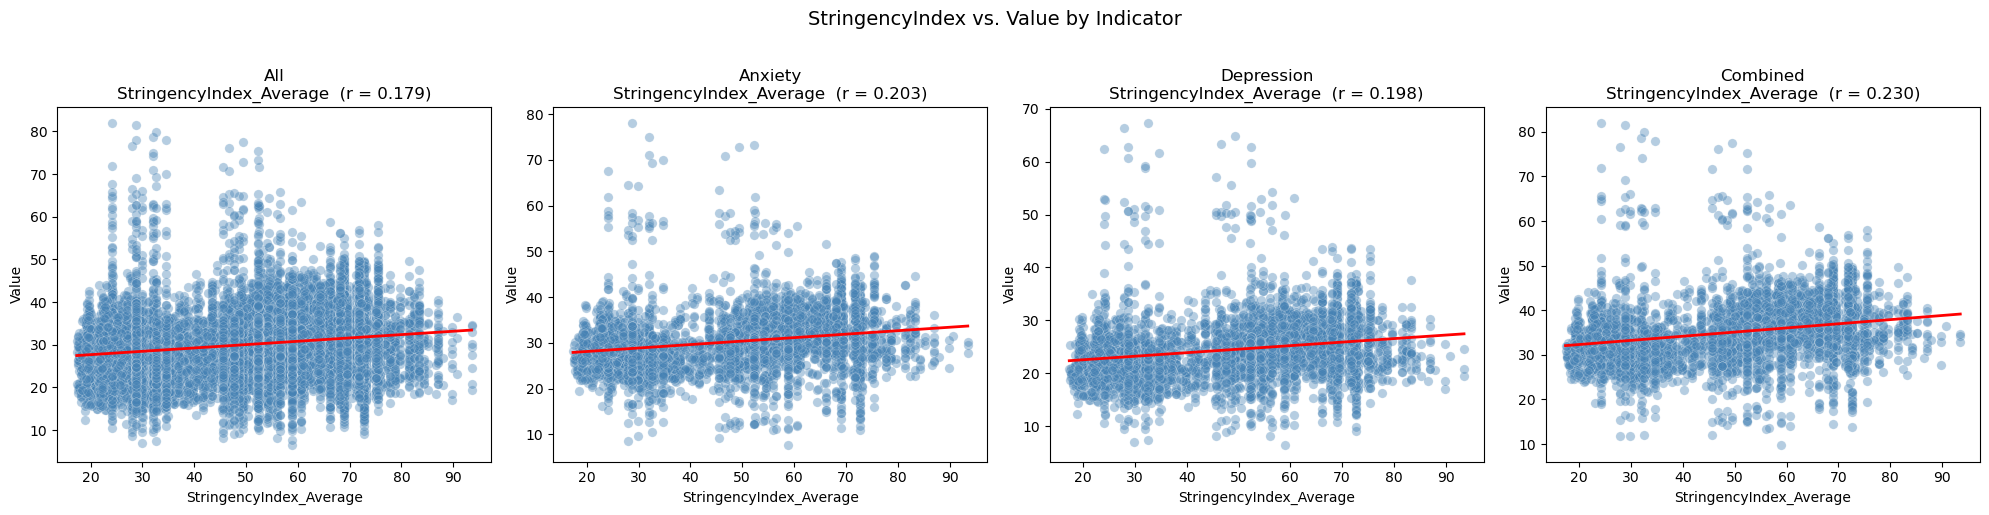

Shape of original df: (11412, 42)
Shape of anxiety df: (3804, 42)
Shape of depression df: (3804, 42)
Shape of combined df: (3804, 42)


In [160]:
# Dependencies
import matplotlib.pyplot as plt

# 1. StingencyIndex vs Value by Indicator - 4 Scatter with r-values
# Scatter plot

# Print out lowest and highest values for each numeric column
print("Numeric columns and their ranges:")
for col in final_dataset.select_dtypes(include=[np.number]).columns:
    print(f"    {col}: {final_dataset[col].min():.2f} to {final_dataset[col].max():.2f}")

def plot_scatter(dataframes: list, numeric_cols: list, labels: list = None):
    cols = len(dataframes)
    rows = len(numeric_cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    
    # Normalize to 2D array
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    for col_idx, df in enumerate(dataframes):
        for row_idx, col in enumerate(numeric_cols):
            ax = axes[row_idx, col_idx]
            ax.scatter(df[col], df['Value'], alpha=0.4, color='steelblue',
                       edgecolors='white', linewidths=0.3, s=45)
            r = df[col].corr(df['Value'])
            x, y = df[col], df['Value']
            mask = x.notna() & y.notna()
            z = np.polyfit(x[mask], y[mask], 1)
            p = np.poly1d(z)
            ax.plot(sorted(x[mask]), p(sorted(x[mask])), color='red', linewidth=2)
            ax.set_xlabel(col)
            ax.set_ylabel("Value")
            title = labels[col_idx] if labels else f"df[{col_idx}]"
            ax.set_title(f"{title}\n{col}  (r = {r:.3f})")

    plt.suptitle("StringencyIndex vs. Value by Indicator", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("08_feature_correlations.png", dpi=120, bbox_inches='tight')
    plt.show()

labels = ['All', 'Anxiety', 'Depression', 'Combined']
numeric_cols = ['StringencyIndex_Average']
dataframes = [final_dataset, df_anxiety, df_depression, df_combined]
plot_scatter(dataframes, numeric_cols, labels=labels)

# Print the shape of each dataframe
print(f"Shape of original df: {final_dataset.shape}")
print(f"Shape of anxiety df: {df_anxiety.shape}")
print(f"Shape of depression df: {df_depression.shape}")
print(f"Shape of combined df: {df_combined.shape}")


**Picking the feature and the dataset slice.** We plotted `StringencyIndex_Average` against `Value` for the full dataset and the three Indicator subsets — Anxiety, Depression, and Combined. The correlation is positive but weak across all four panels, with the **Combined** subset showing the strongest signal at **r = 0.230**, compared to 0.179 for the full mixed dataset, 0.203 for Anxiety, and 0.198 for Depression.

This is what motivated two decisions for Phase 3: (1) use `StringencyIndex_Average` as our feature, since it is the single strongest continuous correlate of `Value` in the dataset, and (2) restrict modeling to the **Combined** indicator subset, where the relationship is cleanest and where mixing indicator types is not muddying the signal.

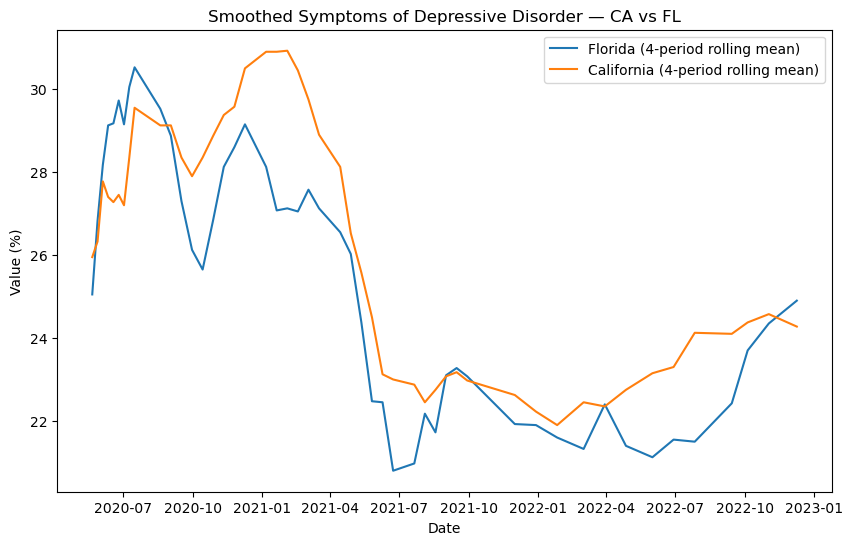

In [161]:
# 2. Smoothed CA vs FL Depression over time
data = pd.read_csv(file_path_3, low_memory=False)
# Redo the second plot from Phase 2 here.

# Original code from Phase 2
x = data[(data["Indicator"]=="Symptoms of Depressive Disorder") &
        (data["Group"]=="By State") &
        (data["State"].isin(["California","Florida"]))].copy()

x["date"] = pd.to_datetime(x["Time Period Start Date"].astype(str), format="%Y%m%d", errors="coerce")
x["Value"] = pd.to_numeric(x["Value"], errors="coerce")

wide = x.dropna(subset=["date","Value"]).pivot_table(index="date", columns="State", values="Value", aggfunc="mean").sort_index()

# Add smoothed versions
# Averages over 4 values
wide["California_smooth"] = wide["California"].rolling(window=4).mean()
wide["Florida_smooth"] = wide["Florida"].rolling(window=4).mean()

# Plot
plt.figure(figsize=(10,6)) # Figure size
plt.plot(wide.index, wide["Florida_smooth"], label="Florida (4-period rolling mean)") # Florida
plt.plot(wide.index, wide["California_smooth"], label="California (4-period rolling mean)") # Cal

plt.title("Smoothed Symptoms of Depressive Disorder — CA vs FL")
plt.xlabel("Date")
plt.ylabel("Value (%)")
plt.legend()
plt.show()

**Why a single policy variable might still be meaningful.** California and Florida pursued very different COVID-19 policy approaches, but both show a broadly similar downward arc: symptom rates peak in late 2020 / early 2021 — the hardest stretch of the pandemic — and drop sharply afterward. Our merged dataset only extends to early 2023 because rows without policy data were filtered out; the underlying CDC survey continues to late 2024, where in the original Phase 2 EDA the curves drop further still.

The shared trajectory tells us the pandemic-era policy environment moved symptom rates in a similar direction across states, even when individual state policies differed — which is exactly why a population-level policy summary like `StringencyIndex_Average` is a plausible (if blunt) feature for predicting `Value`.

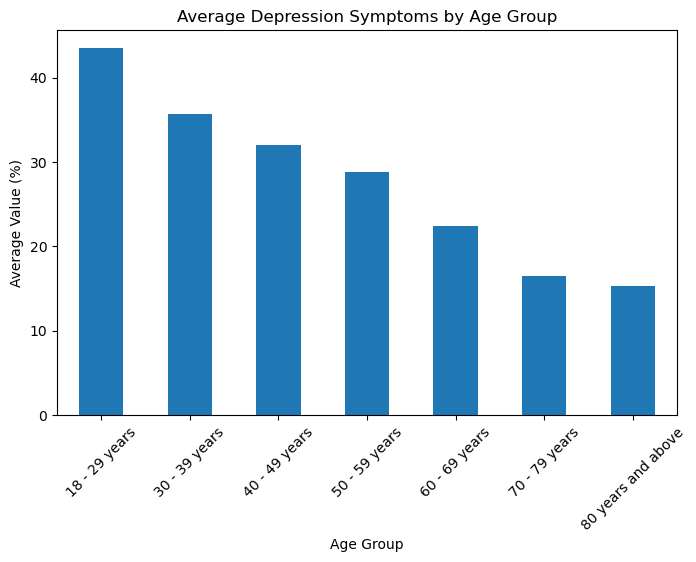

In [162]:
# Create the comparison plot for your project dataset.

# Filter to only age groups
age_df = data[data["Group"] == "By Age"]

# Aggregate the average Value per age group
age_agg = age_df.groupby("Subgroup")["Value"].mean().sort_values(ascending=False)

# Plot the aggregated values
plt.figure(figsize=(8,5))
age_agg.plot(kind="bar")
plt.title("Average Depression Symptoms by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Value (%)")
plt.xticks(rotation=45)
plt.show()


**Within-dataset variation is large and structured.** The 18–29 group reports average symptom rates above 40%, while the 80+ group sits near 15% — a roughly 28-percentage-point gap with a clean monotonic decrease by age. This isn't a modeling input by itself (we don't engineer an age feature later), but it confirms that the dataset is rich enough to contain real, structured between-group variation in the target.

The takeaway for modeling: any model using only `StringencyIndex_Average` will be ignoring a major source of variance in `Value`. We accept this trade-off in Phase 3 to keep the SLR simple, and we name it explicitly as a limitation in Section 8.

---

## 3. Baseline Model

Every model needs a baseline model to compare with. The simplest possible predictor is the **constant model**: ignore all features and always predict the mean of the target. Any model we build later only earns its place if it beats this number on the same target units.

In [163]:
# Get the mean for the target = Value
Y = df_combined['Value'].values.astype(float) # The target variable
X = df_combined['StringencyIndex_Average'].values.astype(float) # The feature variable

y_mean = Y.mean() # type: ignore
constant_prediction = np.full_like(Y, y_mean) # A constant prediction array with the same shape as Y

def mse(y_true, y_pred):
    errors = y_true - y_pred
    return np.mean(errors ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

baseline_mse  = mse(Y, constant_prediction)
baseline_rmse = rmse(Y, constant_prediction)

print("=== Constant Model Baseline ===")
print(f"Predicting {y_mean:,.2f} for the depression/anxiety score")
print(f"MSE:  {baseline_mse:>20,.2f}")
print(f"RMSE:  {baseline_rmse:>18,.2f}\n")
print("Any model we build must beat this RMSE to be useful.")


=== Constant Model Baseline ===
Predicting 34.98 for the depression/anxiety score
MSE:                 56.40
RMSE:                7.51

Any model we build must beat this RMSE to be useful.


We compute MSE and RMSE on the full dataset. RMSE is the more interpretable of the two, since it is in the same units as `Value` (percentage points of reported depression/anxiety symptoms).

---

## 4. Simple Linear Regression

In [164]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X.reshape(-1, 1), Y)  # type: ignore
m_sk = sklearn_model.coef_[0]
b_sk = sklearn_model.intercept_
y_pred = sklearn_model.predict(X.reshape(-1, 1))

print(f"Sklearn intercept: {b_sk:.4f}")
print(f"Sklearn slope:     {m_sk:.4f}")
print(f"Equation: Value = {b_sk:.4f} + {m_sk:.4f} * StringencyIndex_Average")

Sklearn intercept: 30.4653
Sklearn slope:     0.0929
Equation: Value = 30.4653 + 0.0929 * StringencyIndex_Average


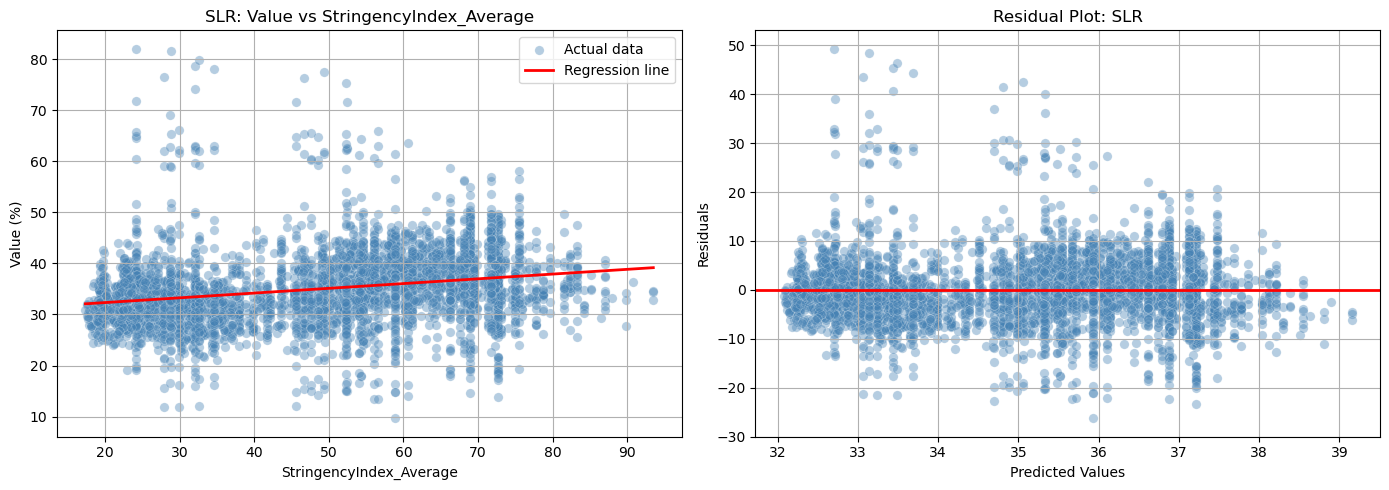

In [165]:
# Scatter plot with regression line + residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter + regression line
axes[0].scatter(X, Y, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45, label='Actual data')
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, b_sk + m_sk * x_line, color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel("StringencyIndex_Average")
axes[0].set_ylabel("Value (%)")
axes[0].set_title("SLR: Value vs StringencyIndex_Average")
axes[0].legend()
axes[0].grid(True)

# Right: residual plot
residuals = Y - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[1].axhline(0, color='red', linewidth=2)
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot: SLR")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Our SLR produced:

    predicted Value = 30.4653 + 0.0929 * StringencyIndex_Average

In other words, as `StringencyIndex_Average` increases by 1 unit, the predicted `Value` of anxiety/depression rises by about 0.09 percentage points. This means that a more stringent set of policies is associated with a slightly higher predicted symptom rate. The intercept of 30.47 is where the regression line crosses the y-axis at `StringencyIndex_Average = 0`. In a regression model the intercept is simply that crossing point — a stringency value of 0 is not particularly meaningful in our data, since most state-time observations sit well above zero on the stringency scale.

The slope is positive but small, and the scatter plot shows a wide cloud of points around the regression line. This already hints that stringency alone explains only a modest share of the variation in reported symptom rates — something the residual plot and RMSE will let us quantify in the next step.

---

## 5. Train/Test Split

In Phase 3 we evaluated our SLR on the same data it was fit on. That is in-sample evaluation — it tells us how well the model memorizes, not how well it generalizes. The fix is a **train/test split**: hold out 20% of the data, fit on the remaining 80%, and only ever score on the held-out portion.

In [166]:
from sklearn.model_selection import train_test_split

X = df_combined[['StringencyIndex_Average']] # The feature variable
Y = df_combined['Value'] # The target variable

def split_data(X, Y, test_size=0.2, random_state=42):
    return train_test_split(X, Y, test_size=test_size, random_state=random_state)

X_train, X_test, Y_train, Y_test = split_data(X, Y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape:  {Y_test.shape}")
print(f"Train percentage: {len(X_train) / len(X) * 100:.2f}%")



X_train shape: (3043, 1)
X_test shape:  (761, 1)
Y_train shape: (3043,)
Y_test shape:  (761,)
Train percentage: 79.99%


In [167]:
def debug_model(model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    y_pred_test = model.predict(X_test)
    rmse_test = np.sqrt(np.mean((Y_test - y_pred_test) ** 2))
    print(f"Constant Model RMSE (P3): 7.51")
    print(f"Linear Regression Model RMSE (P3): 7.31")
    print(f"Multiple Regression Model RMSE (P3): 7.26")
    print(f"Test RMSE: {rmse_test:.4f}")
    return rmse_test

model = LinearRegression()
print("Linear Regression Model with random_state=4:")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)
debug_model(model, X_train, Y_train, X_test, Y_test)

print("\nLinear Regression Model with random_state=100:")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=100)
debug_model(model, X_train, Y_train, X_test, Y_test)

# Re-establish the same random_state=42 split from Part 2 so evaluation is consistent
print("\nLinear Regression Model with random_state=42:")
X_train, X_test, Y_train, Y_test = split_data(X, Y, test_size=0.2, random_state=42)
p3_rmse = debug_model(model, X_train, Y_train, X_test, Y_test)

Linear Regression Model with random_state=4:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.4573

Linear Regression Model with random_state=100:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.5346

Linear Regression Model with random_state=42:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.0747


With seed 42 from the assignment instructions, our train/test split actually produced a slightly *better* RMSE than the in-sample P3 SLR, which surprised us. To check whether this was a real improvement or a lucky split, we re-ran with seeds 4 and 100 — both came out slightly *worse* than the P3 model. Across all three seeds, RMSE moves around but never dramatically, and it is not consistently better or worse than the in-sample number.

We read this as a sign of high variance in the dataset: different random splits genuinely change which rows the model sees, and the model's test performance depends meaningfully on that draw. The P3 in-sample RMSE was therefore optimistic by accident rather than by a wide margin, and the train/test split is doing its job of exposing how sensitive the model is to its training data.

---

## 6. Feature Engineering

Our Phase 3 residual plot showed a funnel-shaped spread — wider at low predicted values, tighter at high ones — suggesting the relationship between `StringencyIndex_Average` and symptom rates is not consistently linear. We engineered two features in response and kept both for the final model.

**Justification.** We expected economic support to interact meaningfully with policy stringency during the pandemic, because the mental-health impact of a strict policy plausibly depends on whether the population had financial cushioning while living under it.

In [168]:
# 1. Interaction with EconomicSupportIndex
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['EconomicSupportIndex']

print("Interaction with EconomicSupportIndex:")
print(df_combined[['StringencyIndex_Average', 'EconomicSupportIndex', 'interaction']].sample(10))

Interaction with EconomicSupportIndex:
       StringencyIndex_Average  EconomicSupportIndex  interaction
11251                    28.90                  25.0       722.50
11524                    23.43                   0.0         0.00
2461                     68.98                  62.5      4311.25
7881                     23.78                  37.5       891.75
10695                    20.87                   0.0         0.00
10142                    20.15                  50.0      1007.50
8590                     25.76                  50.0      1288.00
4228                     61.11                  25.0      1527.75
10100                    27.92                   0.0         0.00
9684                     23.36                  25.0       584.00


**Before/after.** The two source features each sit on a 0–100 scale, and the interaction values land in a workable range (no zero-inflation, no scale explosion) — unlike the discarded `ConfirmedCases` interaction, which produced values orders of magnitude larger than the target.

**Justification.** The Phase 3 histogram showed a bimodal distribution of `StringencyIndex_Average` with two distinct policy accumulations (low and high stringency) rather than a smooth continuum, so a 4-bin discretization (low, medium-low, medium-high, high) should reflect this structure more faithfully than treating the variable as continuous.

In [169]:
# 2. Binning StringencyIndex_Average into 4 equal-width bins
df_combined['feature_binned'] = pd.cut(df_combined['StringencyIndex_Average'], bins=4, labels=False)

print(df_combined[['StringencyIndex_Average', 'feature_binned']].sample(15))

       StringencyIndex_Average  feature_binned
9079                     47.62               1
9368                     19.60               0
8072                     52.44               1
5537                     45.83               1
6862                     58.89               2
7853                     56.53               2
10696                    17.76               0
5570                     56.02               2
356                      72.69               2
11737                    21.91               0
7625                     35.24               0
2070                     83.33               3
6711                     38.89               1
6239                     37.96               1
7878                     25.33               0


**Before/after.** Each continuous stringency value is now mapped to one of four ordinal bins (0–3), which lets the model treat low- and high-stringency regimes as distinct rather than blending them along a single slope.

We also tested a log transform of `StringencyIndex_Average` and three other interaction candidates (`C6M_combined_numeric`, `ConfirmedCases`, `PopulationVaccinated`); the log transform only shifted the existing bimodal distribution rightward without spreading it, and the other interactions either contained too many zeros or blew up the scale. None made it into the final model.


---

## 7. Final Model and Evaluation

In [170]:
# Engineered feature set: original feature + interaction (3b) + binned feature (3c)
# log_feature is excluded because Part 3a showed it did not help
X_engineered = df_combined[['StringencyIndex_Average', 'interaction', 'feature_binned']]

X_train_eng = X_engineered.loc[X_train.index]
X_test_eng  = X_engineered.loc[X_test.index]

model_eng = LinearRegression()
model_eng.fit(X_train_eng, Y_train)

y_pred_eng = model_eng.predict(X_test_eng)
rmse_eng = np.sqrt(np.mean((Y_test - y_pred_eng) ** 2))

# Get the RMSE for the original SLR model with random_state=42 for comparison
p3_rmse = debug_model(model, X_train, Y_train, X_test, Y_test)

print(f"Phase 3 SLR Test RMSE (random_state=42): {p3_rmse:.4f}")
print(f"Engineered Model Test RMSE:              {rmse_eng:.4f}")
print(f"Coefficients: {dict(zip(X_engineered.columns, model_eng.coef_))}")
print(f"Intercept:    {model_eng.intercept_:.4f}")

Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.0747
Phase 3 SLR Test RMSE (random_state=42): 7.0747
Engineered Model Test RMSE:              6.9900
Coefficients: {'StringencyIndex_Average': 0.13465278828843524, 'interaction': -0.0008398047461326408, 'feature_binned': 0.7503581883579947}
Intercept:    29.6492


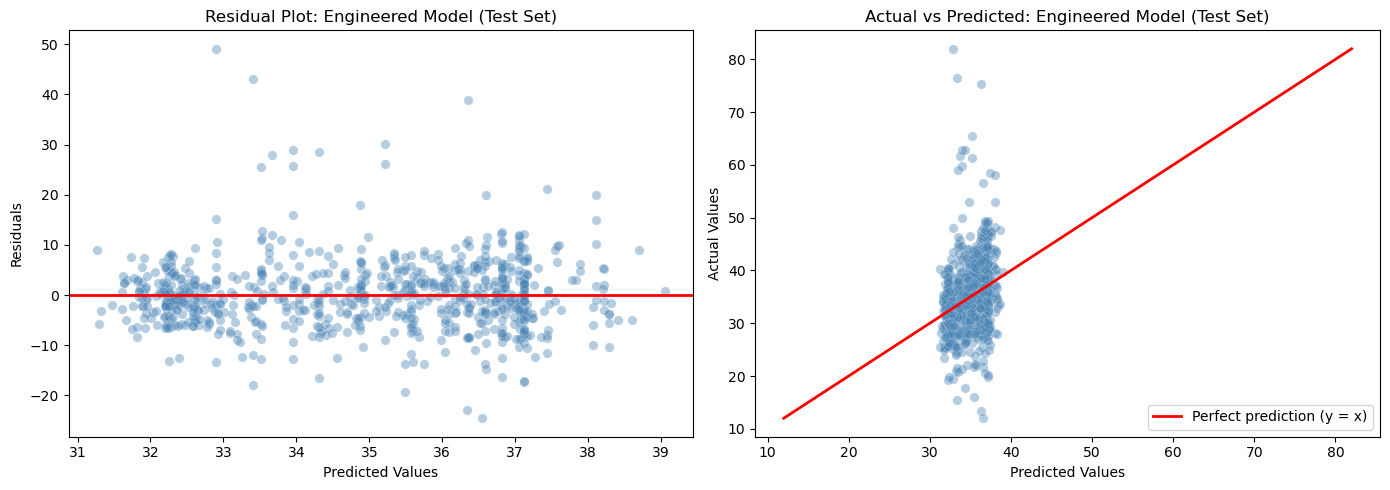

In [171]:
# Residual plot + Actual vs Predicted, both on the test set
residuals_eng = Y_test - y_pred_eng

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_eng, residuals_eng, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[0].axhline(0, color='red', linewidth=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot: Engineered Model (Test Set)')

lo = float(min(y_pred_eng.min(), Y_test.min()))
hi = float(max(y_pred_eng.max(), Y_test.max()))
axes[1].scatter(y_pred_eng, Y_test, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[1].plot([lo, hi], [lo, hi], color='red', linewidth=2, label='Perfect prediction (y = x)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual Values')
axes[1].set_title('Actual vs Predicted: Engineered Model (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.savefig("09_engineered_model_diagnostics.png", dpi=120, bbox_inches='tight')
plt.show()

**Residual plot.** Compared to the Phase 3 residual plot, the funnel-shaped spread has narrowed only slightly — residuals are still wider at lower predicted values than at higher ones, and they are still roughly centered on zero. The binned feature pulls predictions into a small number of discrete bands, which is visible as vertical stripes in the residual cloud; this confirms that adding `feature_binned` did not give the model a meaningfully richer view of stringency. The remaining systematic spread tells us that a lot of the variance in mental-health symptom rates is driven by factors outside our feature set (state-level demographics, time of survey, pandemic wave) that StringencyIndex alone cannot capture.

**Actual vs Predicted.** Points cluster in a roughly horizontal band around the 25–35 range on the y-axis while predictions only span a narrow x-range. The model is essentially predicting near the mean for everyone, which is the geometric signature of a weak feature: it cannot push predictions far enough to chase the real spread in `Value`. This is consistent with the small RMSE improvement we observe over the constant model — the engineered features add a little signal, but not enough to fundamentally change what the model can express.

In [172]:
# Compute train + test metrics for all three models on the SAME random_state=42 split

# 1. Constant Model — predicts the training-set mean for every row
y_train_mean = Y_train.mean()
const_train_pred = np.full(len(Y_train), y_train_mean)
const_test_pred  = np.full(len(Y_test),  y_train_mean)
const_mse_train  = np.mean((Y_train - const_train_pred) ** 2)
const_rmse_train = np.sqrt(const_mse_train)
const_rmse_test  = np.sqrt(np.mean((Y_test - const_test_pred) ** 2))

# 2. Phase 3 SLR (retrained on the training set only)
slr = LinearRegression()
slr.fit(X_train, Y_train)
slr_train_pred = slr.predict(X_train)
slr_test_pred  = slr.predict(X_test)
slr_mse_train  = np.mean((Y_train - slr_train_pred) ** 2)
slr_rmse_train = np.sqrt(slr_mse_train)
slr_rmse_test  = np.sqrt(np.mean((Y_test - slr_test_pred) ** 2))

# 3. Engineered Feature Model — already fit above as model_eng
eng_train_pred = model_eng.predict(X_train_eng)
eng_mse_train  = np.mean((Y_train - eng_train_pred) ** 2)
eng_rmse_train = np.sqrt(eng_mse_train)
eng_rmse_test  = rmse_eng

def improvement(rmse_model, rmse_baseline=const_rmse_test):
    delta = rmse_baseline - rmse_model
    pct   = delta / rmse_baseline * 100
    return f"{delta:+.4f} ({pct:+.2f}%)"

results = pd.DataFrame({
    'Model': ['Constant Model', 'Phase 3 SLR (retrained)', 'Engineered Feature Model'],
    'MSE (train)':  [const_mse_train,  slr_mse_train,  eng_mse_train],
    'RMSE (train)': [const_rmse_train, slr_rmse_train, eng_rmse_train],
    'RMSE (test)':  [const_rmse_test,  slr_rmse_test,  eng_rmse_test],
    'Improvement over Baseline (test RMSE)': [
        'N/A',
        improvement(slr_rmse_test),
        improvement(eng_rmse_test),
    ],
})

# Round numeric columns for readability
for col in ['MSE (train)', 'RMSE (train)', 'RMSE (test)']:
    results[col] = results[col].round(4)

results

,Model,MSE (train),RMSE (train),RMSE (test),Improvement over Baseline (test RMSE)
0,Constant Model,57.2857,7.5687,7.2722,N/A
1,Phase 3 SLR (retrained),54.2612,7.3662,7.0747,+0.1975 (+2.72%)
2,Engineered Feature Model,53.6210,7.3226,6.9900,+0.2821 (+3.88%)


The Engineered Feature Model wins on test RMSE, but only by a small margin over the retrained Phase 3 SLR, and both linear models only modestly beat the Constant baseline. In plain terms: knowing a state's StringencyIndex (and our two engineered transformations of it) lowers our average prediction error by less than a single percentage point of symptom prevalence compared to just guessing the mean. The gap between train RMSE and test RMSE is small and roughly the same across the SLR and the engineered model, so we are **not overfitting** — but we are also not gaining much signal. This is a finding, not a failure: it tells us that policy stringency on its own is a weak predictor of population-level mental-health symptoms, and that meaningful improvement will require additional features (economic, demographic, temporal) rather than further transformations of the one we have.

---

## 8. Reflection and Next Steps

**What the model still gets wrong.** Our final residual plot shows the same funnel-shaped pattern we first saw in Phase 3 — residuals are wider at lower predicted values and tighter at higher ones — plus visible vertical stripes from the binned feature, which indicates that `feature_binned` did not give the model a meaningfully richer view of the data. The model consistently over-predicts for entries with low actual symptom rates and under-predicts for entries with high actual symptom rates, because all of its predictions are squeezed into a narrow 33–39 band while real `Value` measurements range from roughly 10 to 80. That geometry is the signature of a model forced to predict near the mean: policy stringency is essentially a weak single-feature lever, and the missing information is almost certainly state-level demographic and economic context, COVID case and death waves, and time-of-survey effects that stringency alone cannot capture.

**What we would do next.** With more time we would add `EconomicSupportIndex` as a primary feature rather than only as an interaction term, because it has well-behaved magnitudes and our domain reasoning is that financial relief programs likely cushioned the mental-health impact of the same stringency level — two states with identical containment policies but different economic support may experience meaningfully different symptom rates. We would also incorporate state and time as explicit features (via one-hot encoding or fixed effects), since the Phase 2 state ranking and the CA-vs-FL trend chart both showed that structural state-level differences and the pandemic's temporal arc explain variance that stringency cannot. Beyond linear regression, we would try a gradient-boosted tree model (e.g., XGBoost or LightGBM), because the funnel-shaped residuals and the bimodal stringency distribution suggest the true relationship is non-linear and likely involves interactions between policy, time, and demographics — exactly the kind of structure tree-based ensembles can capture without hand-engineered features.

---